In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from tensorflow.keras import layers, models

#remove blob from the url
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [15]:
pd.set_option('display.max_columns', None)
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [16]:
#Data analysis - basic
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
df['gender'].value_counts()


gender
Male      3555
Female    3488
Name: count, dtype: int64

In [18]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce') 
df['gender'] = df['gender'].map({"Female":0, "Male":1})
df['Churn'] = df['Churn'].map({"No":0, "Yes":1})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [19]:
numerical_features = df.select_dtypes(['float64','int64']).columns
numerical_features

Index(['gender', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'Churn'],
      dtype='object')

Text(0.5, 1.0, 'Correlation heatmap of numerical features')

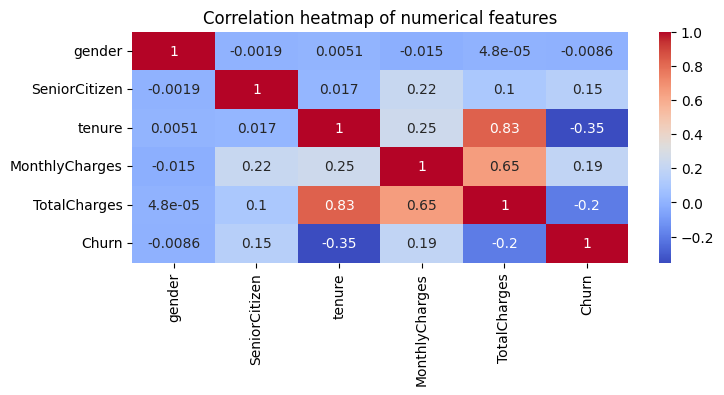

In [20]:
plt.figure(figsize=(8,3))
correlation = df[numerical_features].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation heatmap of numerical features")

In [21]:
#nan values
df.isna().sum()


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [22]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [23]:
print("\n========= Feature Selection =========\n")
#customer id, churn -> target
# numerical_features = ["gender", "SeniorCitizen", "tenure",
#                       "MonthlyCharges", "TotalCharges",
#                      "Partner", "Dependents", "PhoneService",
#                       "PaperlessBilling"]
numerical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents','tenure', 'PhoneService', 'MultipleLines', 'InternetService','OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport','StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling','PaymentMethod', 'MonthlyCharges', 'TotalCharges']






========= Feature Selection =========



In [24]:
for col in numerical_features:
  if df[col].dtype == 'object':
    df[col] = pd.factorize(df[col])[0]

numerical_features = [f for f in numerical_features if f in df.columns]

X = df[numerical_features] #features
y = df['Churn']

rf = RandomForestClassifier(n_estimators=150, random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=5)
rfe.fit(X, y)

,estimator,RandomForestC...ndom_state=42)
,n_features_to_select,5
,step,1
,verbose,0
,importance_getter,'auto'
,n_estimators,150
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [25]:
selected_features = [feature for feature, selected in
                     zip(numerical_features, rfe.support_) if selected]
print(selected_features)

['tenure', 'OnlineSecurity', 'Contract', 'MonthlyCharges', 'TotalCharges']


             feature  importance
18      TotalCharges    0.190183
17    MonthlyCharges    0.177578
4             tenure    0.159213
14          Contract    0.078628
16     PaymentMethod    0.055859
8     OnlineSecurity    0.045479
11       TechSupport    0.038758
0             gender    0.027897
15  PaperlessBilling    0.025124
7    InternetService    0.024936
9       OnlineBackup    0.024868
6      MultipleLines    0.022667
2            Partner    0.022537
10  DeviceProtection    0.022380
1      SeniorCitizen    0.020294
12       StreamingTV    0.019849
13   StreamingMovies    0.019843
3         Dependents    0.019764
5       PhoneService    0.004145


Text(0.5, 1.0, 'Feature importances')

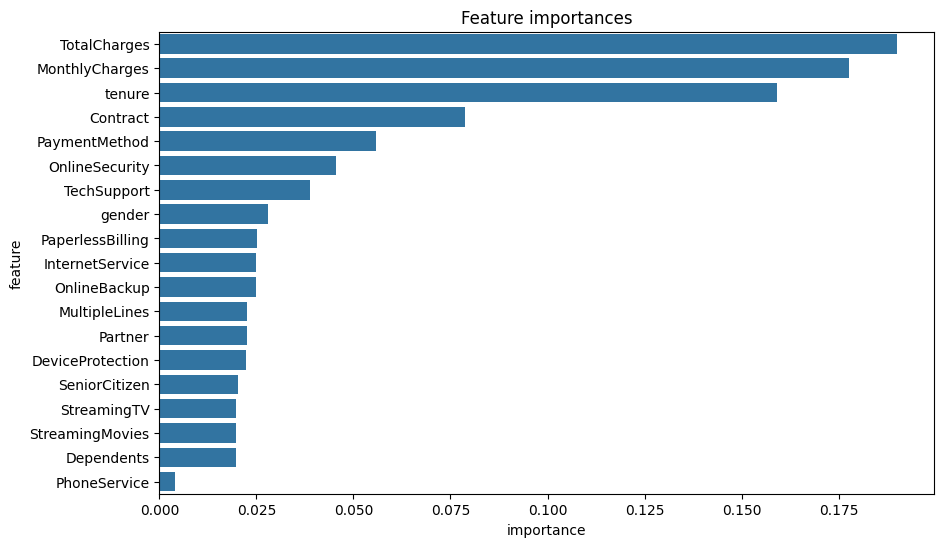

In [26]:
rf.fit(X,y)
importances = pd.DataFrame({"feature":numerical_features,
                            "importance":rf.feature_importances_})

importances = importances.sort_values('importance', ascending=False)
print(importances)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature',data=importances)
plt.title("Feature importances")

In [27]:
# model build

In [28]:
X = df[selected_features]
y = df['Churn']

In [29]:
X.head(2)

,tenure,OnlineSecurity,Contract,MonthlyCharges,TotalCharges
0,1,0,0,29.85,29.85
1,34,1,1,56.95,1889.50


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,random_state=42)

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
import pickle

In [32]:
#pickle file -> 010101010111101010
# read binary, write binary, read, write
with open('scaler.pkl', "wb") as f:
  pickle.dump(scaler, f)

In [33]:
def create_model(hp=None):
  if hp:
    model = models.Sequential() # Sequential Method is an another way to gue every layer together 
    #input layer + hidden _ 1 created here
    model.add(layers.Dense(
        units =hp.Choice('units_1',values=[32,64,128]),
        activation = 'relu',
        input_shape = (X_train_scaled.shape[1],)
    ))

    if hp.Boolean('second_layer'):
      model.add(layers.Dense(
          units=hp.Choice('units_2',values=[16,32]),
          activation='relu'
      ))
    #output layer
    model.add(layers.Dense(1, activation='sigmoid'))

    #compile
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
  else:
    #default
    model = models.Sequential([
        layers.Dense(64, activation='relu',input_shape=(X_train_scaled.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(1,activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy', # If you are using binry classification your loss will be binary_crossentropy
        metrics=['accuracy'])
  return model

In [34]:
initial_model = create_model()
initial_model.summary()

c:\Users\Hemant\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history = initial_model.fit(X_train_scaled, y_train,
                            epochs=50,
                            batch_size=32,
                            validation_split=0.20)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7302 - loss: 0.6043 - val_accuracy: 0.7507 - val_loss: 0.5622
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 0.5831 - val_accuracy: 0.7507 - val_loss: 0.5626
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7304 - loss: 0.5830 - val_accuracy: 0.7507 - val_loss: 0.5644
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 0.5832 - val_accuracy: 0.7507 - val_loss: 0.5627
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7304 - loss: 0.5832 - val_accuracy: 0.7507 - val_loss: 0.5626
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 0.5831 - val_accuracy: 0.7507 - val_loss: 0.5638
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 0.5837 - val_accuracy: 0.7507 - val_loss: 0.5627
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 0.5834 - val_accuracy: 0.

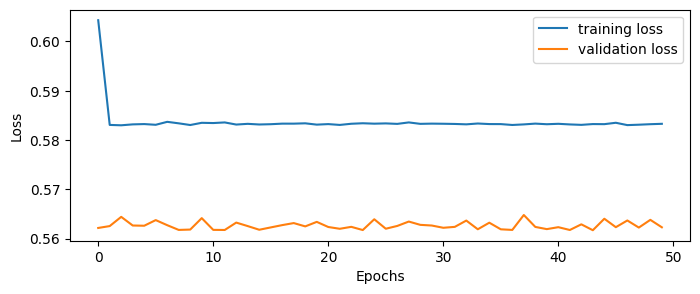

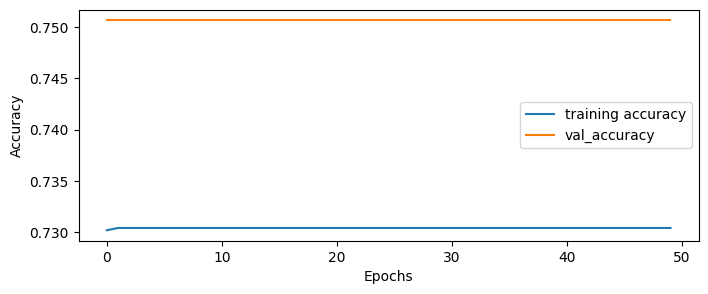

In [36]:
plt.figure(figsize=(8,3))
plt.plot(history.history['loss'],label='training loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()


plt.figure(figsize=(8,3))
plt.plot(history.history['accuracy'],label='training accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [37]:
loss, accuracy = initial_model.evaluate(X_test_scaled, y_test)
print(f"Initial model Loss : {loss}")
print(f"Initial model Accuracy : {accuracy}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7353 - loss: 0.5779 
Initial model Loss : 0.5779462456703186
Initial model Accuracy : 0.7352732419967651


In [38]:
import keras_tuner as kt

In [39]:
tuner = kt.RandomSearch(
    create_model,
    objective='val_accuracy',
    max_trials=5,
    directory = 'keras_tuning',
    project_name = "churn_prediction"
)
import tensorflow as tf

In [40]:
#early stopping
stop_early = tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=5)

In [41]:
tuner.search(
    X_train_scaled, y_train,
    epochs=20,
    validation_split=0.20,
    callbacks=[stop_early]
)

Trial 5 Complete [00h 00m 08s]
val_accuracy: 0.7506654858589172

Best val_accuracy So Far: 0.7506654858589172
Total elapsed time: 00h 00m 32s


In [42]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hps)
for param in best_hps.values:
  print(f"{param} : {best_hps.get(param)}")

units_1 : 128
second_layer : False


In [43]:
best_model = tuner.hypermodel.build(best_hps)
best_history = best_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7300 - loss: 0.6769 - val_accuracy: 0.7507 - val_loss: 0.6622
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 0.6535 - val_accuracy: 0.7507 - val_loss: 0.6380
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 0.6345 - val_accuracy: 0.7507 - val_loss: 0.6191
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 0.6199 - val_accuracy: 0.7507 - val_loss: 0.6046
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 0.6090 - val_accuracy: 0.7507 - val_loss: 0.5934
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7304 - loss: 0.6010 - val_accuracy: 0.7507 - val_loss: 0.5853
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 0.5953 - val_accuracy: 0.7507 - val_loss: 0.5791
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7304 - loss: 0.5912 - val_accuracy: 0.

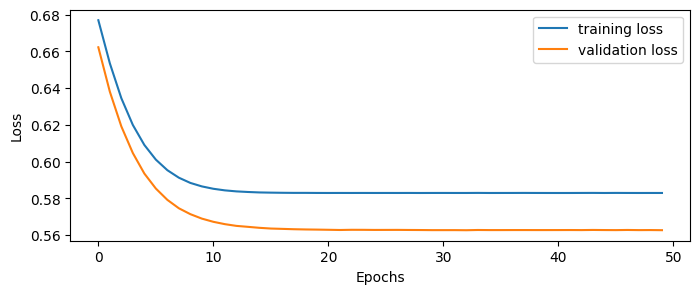

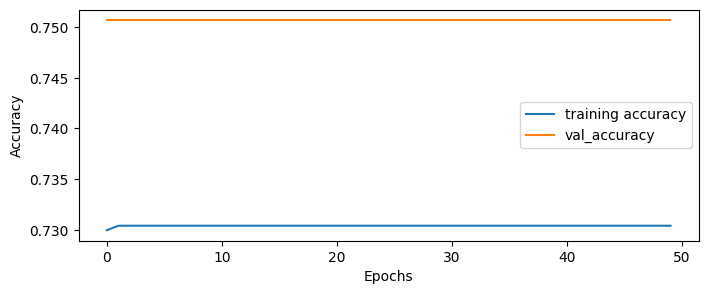

In [44]:
plt.figure(figsize=(8,3))
plt.plot(best_history.history['loss'],label='training loss')
plt.plot(best_history.history['val_loss'],label='validation loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()


plt.figure(figsize=(8,3))
plt.plot(best_history.history['accuracy'],label='training accuracy')
plt.plot(best_history.history['val_accuracy'],label='val_accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [45]:
best_loss, best_accuracy = best_model.evaluate(X_test_scaled, y_test)
print(f"Best model Loss : {best_loss}")
print(f"Best model Accuracy : {best_accuracy}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7353 - loss: 0.5780 
Best model Loss : 0.5779889822006226
Best model Accuracy : 0.7352732419967651


In [46]:
print(f"Improvement : {(81-78)}")

Improvement : 3


In [47]:
best_model.save('best_churn_model.h5')

#best fetures
with open("selected_features.pkl","wb") as f:
  pickle.dump(selected_features, f)

In [48]:
selected_features

['tenure', 'OnlineSecurity', 'Contract', 'MonthlyCharges', 'TotalCharges']

In [49]:
#load all your files
def load_model_components():
  #load your neural network model
  model = tf.keras.models.load_model('best_churn_model.h5')
  #load scalar
  with open('scaler.pkl', "rb") as f:
    scaler = pickle.load(f)
  #load selected featiures
  with open('selected_features.pkl', "rb") as f:
    selected_features = pickle.load(f)

  return model, scaler, selected_features

In [50]:
def predict_churn(*args):
  model, scaler, selected_features = load_model_components()
  input_data = pd.DataFrame([args], columns=selected_features)
  input_scaled = scaler.transform(input_data)
  prediction = model.predict(input_scaled)[0][0]
  print(f"prediction : {prediction}")
  probability = float(prediction)
  churn_status = "Yes" if probability > 0.50 else "No"

  return {
      "Churn Probability":probability,
      "Will Customer Churn":churn_status
  }

In [51]:
selected_features

# [34, 1, 1, 56.96, 1900]

['tenure', 'OnlineSecurity', 'Contract', 'MonthlyCharges', 'TotalCharges']

In [52]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,29.85,29.85,0
1,5575-GNVDE,1,0,1,0,34,1,1,0,1,1,1,0,0,0,1,1,1,56.95,1889.50,0


In [53]:
predict_churn(34, 1, 1, 56.96, 1900)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
prediction : 0.26897087693214417


{'Churn Probability': 0.26897087693214417, 'Will Customer Churn': 'No'}